In [12]:
# 如果 python 版本 >3.12 ，请将下行注释掉，否则 matplotlib 不会显示图像
# %matplotlib inline
%time from hikyuu.interactive import *
iodog.open()

import matplotlib

# 设置中文字体为黑体
matplotlib.rcParams['font.sans-serif'] = 'SimHei'


CPU times: user 936 μs, sys: 0 ns, total: 936 μs
Wall time: 1.04 ms


# 一、策略分析

## 原始描述

买入条件：周线MACD零轴下方底部金叉买入30%

卖出条件：日线级别 跌破 20日线 卖出50%持仓


## 策略分析

市场环境：无

系统有效性：无

信号指示器：
- 买入信号：周线MACD零轴下方底部金叉，即周线的DIF>DEA金叉时买入（快线：DIF，慢线DEA）
- 卖出信号：日线级别 跌破 20日均线

止损/止盈：无

资金管理：
- 买入：30% （不明确，暂且当做当前现金的30%）
- 卖出：已持仓股票数的50%

盈利目标：

移滑价差：


# 二、实现系统部件

## 定义信号指示器

In [2]:
def getNextWeekDate(week):
    """获取指定日期的下一周周一日期"""
    from datetime import timedelta
    py_week = week.datetime()
    next_week_start = py_week + timedelta(days = 7 - py_week.weekday())
    return Datetime(next_week_start)

In [ ]:
s = sm['sz300498']

In [21]:
help(s)

Help on Stock in module hikyuu.cpp.core313 object:

class Stock(pybind11_builtins.pybind11_object)
 |  证券对象
 |
 |  Method resolution order:
 |      Stock
 |      pybind11_builtins.pybind11_object
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __eq__(...)
 |      __eq__(self: hikyuu.cpp.core313.Stock, arg0: hikyuu.cpp.core313.Stock) -> bool
 |
 |  __getstate__(...)
 |      __getstate__(self: hikyuu.cpp.core313.Stock, /) -> tuple
 |
 |  __hash__ lambda self from hikyuu.extend
 |
 |  __init__(...)
 |      __init__(*args, **kwargs)
 |      Overloaded function.
 |
 |      1. __init__(self: hikyuu.cpp.core313.Stock) -> None
 |
 |      2. __init__(self: hikyuu.cpp.core313.Stock, market: str, code: str, name: str) -> None
 |
 |      3. __init__(self: hikyuu.cpp.core313.Stock, arg0: hikyuu.cpp.core313.Stock) -> None
 |
 |  __ne__(...)
 |      __ne__(self: hikyuu.cpp.core313.Stock, arg0: hikyuu.cpp.core313.Stock) -> bool
 |
 |  __repr__(...)
 |      __repr__(self: hikyuu.cpp.core313

In [39]:
s.get_finance_info()

params[baoliu2(double): 9, bgu(double): 0, changqifuzhai(double): 2.81534e+10, code(string): 300498, cunhuo(double): 2.12649e+11, faqirenfarengu(double): 6.43247e+10, farengu(double): 7.58136e+11, gudingzichan(double): 3.47364e+11, gudongrenshu(double): 81077, guojiagu(double): 1.003e+07, hgu(double): 0, industry(double): 17, ipo_date(int): 20151102, jinglirun(double): 5.25584e+10, jingyingxianjinliu(double): 8.19865e+10, jingzichan(double): 4.38634e+11, lirunzonghe(double): 5.55336e+10, liudongfuzhai(double): 2.80853e+11, liudongzichan(double): 3.23403e+11, liutongguben(double): 5.95254e+09, market(string): SZ, meigujingzichan(double): 6.33, province(double): 12, shuihoulirun(double): 5.41747e+10, touzishouyi(double): 2.47187e+09, updated_date(int): 20260224, weifenpeilirun(double): 2.40245e+11, wuxingzichan(double): 1.44128e+10, yingshouzhangkuan(double): 9.49298e+09, yingyelirun(double): 5.621e+10, zhigonggu(double): 7900, zhuyinglirun(double): 6.60723e+11, zhuyingshouru(double): 7.

In [40]:
help(s.get_kdata(Query(-150)))

Help on KData in module hikyuu.cpp.core313 object:

class KData(pybind11_builtins.pybind11_object)
 |  通过 Stock.getKData 获取的K线数据，由 KRecord 组成的数组，可象 list 一样进行遍历
 |
 |  Method resolution order:
 |      KData
 |      pybind11_builtins.pybind11_object
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __eq__(...)
 |      __eq__(self: hikyuu.cpp.core313.KData, arg0: hikyuu.cpp.core313.KData) -> bool
 |
 |  __getitem__(...)
 |      __getitem__(self: hikyuu.cpp.core313.KData, arg0: object) -> object
 |
 |  __getstate__(...)
 |      __getstate__(self: hikyuu.cpp.core313.KData, /) -> tuple
 |
 |  __init__(...)
 |      __init__(self: hikyuu.cpp.core313.KData) -> None
 |
 |  __iter__(...)
 |      __iter__(self: hikyuu.cpp.core313.KData) -> collections.abc.Iterator[hikyuu.cpp.core313.KRecord]
 |
 |  __len__(...)
 |      __len__(self: hikyuu.cpp.core313.KData) -> int
 |
 |  __ne__(...)
 |      __ne__(self: hikyuu.cpp.core313.KData, arg0: hikyuu.cpp.core313.KData) -> bool
 |
 |  __repr__(..

In [41]:
s.get_kdata(Query(-150)).to_df()

,datetime,open,high,low,close,amount,volume
0,2025-07-31,17.61,17.62,17.29,17.31,91888.1,528700.0
1,2025-08-01,17.32,17.51,17.30,17.31,63945.5,367988.0
2,2025-08-04,17.29,17.46,17.24,17.41,51133.5,294454.0
3,2025-08-05,17.41,17.61,17.37,17.53,59269.0,338589.0
4,2025-08-06,17.52,17.57,17.33,17.53,57163.0,327760.0
...,...,...,...,...,...,...,...
145,2026-03-11,16.89,17.26,16.78,17.15,81003.0,475526.0
146,2026-03-12,17.25,17.65,16.93,17.54,154107.3,886736.0
147,2026-03-13,17.60,17.70,17.39,17.43,93702.2,534160.0
148,2026-03-16,17.48,17.77,17.45,17.55,86710.1,493430.0


In [4]:
s.get_kdata(Query(-150)).plot(new=False)

kdata is None


In [3]:
def DEMO_SG(self, k):
    """
    买入信号：周线MACD零轴下方底部金叉，即周线的DIF>DEA金叉时买入
    卖出信号：日线级别 跌破 20日均线
    
    参数：
    week_macd_n1：周线dif窗口
    week_macd_n2: 周线dea窗口
    week_macd_n3: 周线macd平滑窗口
    day_n: 日均线窗口
    """
    if (len(k) == 0):
        return
    
    stk = k.get_stock()
    
    #-----------------------------
    #计算日线级别的卖出信号        
    #-----------------------------
    day_c = CLOSE(k)
    day_ma = MA(day_c, self.get_param("day_n"))
    day_x = day_c < day_ma  #收盘价小于均线
    for i in range(day_x.discard, len(day_x)):
        if day_x[i] >= 1.0:
            self._add_sell_signal(k[i].datetime)

    #-----------------------------
    #计算周线级别的买入信号        
    #-----------------------------
    week_q = Query(k[0].datetime, k[-1].datetime.next_day(), ktype=Query.WEEK)
    week_k = k.get_stock().get_kdata(week_q)
    
    n1 = self.get_param("week_macd_n1")
    n2 = self.get_param("week_macd_n2")
    n3 = self.get_param("week_macd_n3")
    m = MACD(CLOSE(week_k), n1, n2, n3)
    fast = m.get_result(1)
    slow = m.get_result(2)
    
    discard = m.discard if m.discard > 1 else 1
    for i in range(discard, len(m)):
        if (fast[i-1] < slow[i-1] and fast[i] > slow[i]):
            #当周计算的结果，只能作为下周一的信号
            self._add_buy_signal(week_k[i].datetime.next_week())
         

## 定义资金管理策略

In [4]:
class DEMO_MM(MoneyManagerBase):
    """
    买入：30% （不明确，暂且当做当前现金的30%）
    卖出：已持仓股票数的50%
    """
    def __init__(self):
        super(DEMO_MM, self).__init__("MACD_MM")
        
    def _reset(self):
        pass
    
    def _clone(self):
        return DEMO_MM()
        
    def _get_buy_num(self, datetime, stk, price, risk, part_from):
        tm = self.tm
        cash = tm.current_cash
        
        #可以不用考虑最小交易单位的问题，已经自动处理
        # return int(cash*0.3/price) #返回类型必须是int
        return cash / price
    
    def _get_sell_num(self, datetime, stk, price, risk, part_from):
        tm = self.tm
        position = tm.get_position(datetime, stk)
        total_num = position.number
        num = int(total_num * 0.5)
        return num if num >= 100 else 0

# 三、构建并运行系统

## 设定系统参数


In [5]:
#账户参数
init_cash = 100000 #账户初始资金
init_date = Datetime('1990-1-1') #账户建立日期

#信号指示器参数
week_n1 = 12
week_n2 = 26
week_n3 = 9
day_n = 20

#选定标的，及测试区间
stk = sm['sz000001']
start_date = Datetime('2017-01-01')  #如果是同一级别K线，可以使用索引号，使用了不同级别的K线数据，建议还是使用日期作为参数
end_date = Datetime()

## 构建系统实例

In [6]:
#创建账户
my_tm = crtTM(date=init_date, init_cash = init_cash, cost_func=TC_FixedA())

#创建系统实例
my_sys = SYS_Simple()

#绑定账户
my_sys.tm = my_tm

#绑定信号指示器
# !注意
# 受限与 pybind11 的限制，这里不能直接使用 my_sys.sg = crtSG(  或 my_sys.mm = DEMO_MM() , 需要先生成 Python 对象的实例再赋值
my_sg = crtSG(DEMO_SG, 
              {'week_macd_n1': week_n1, 'week_macd_n2': week_n2, 'week_macd_n3': week_n3, 'day_n': day_n}, 
                'DEMO_SG') 
my_sys.sg = my_sg
my_sys.sg.set_param('alternate', False)

#绑定资金管理策略
my_mm = DEMO_MM()
my_sys.mm = my_mm

## 运行系统

In [7]:
iodog.close()
q = Query(start_date, end_date, ktype=Query.DAY)
my_sys.run(stk, q)

#将交易记录及持仓情况，保存在临时目录，可用Excel查看
#临时目录一般设置在数据所在目录下的 tmp 子目录
#如果打开了excel记录，再次运行系统前，记得先关闭excel文件，否则新的结果没法保存
# my_tm.tocsv(sm.tmpdir())

# 四、查看资金曲线及绩效统计

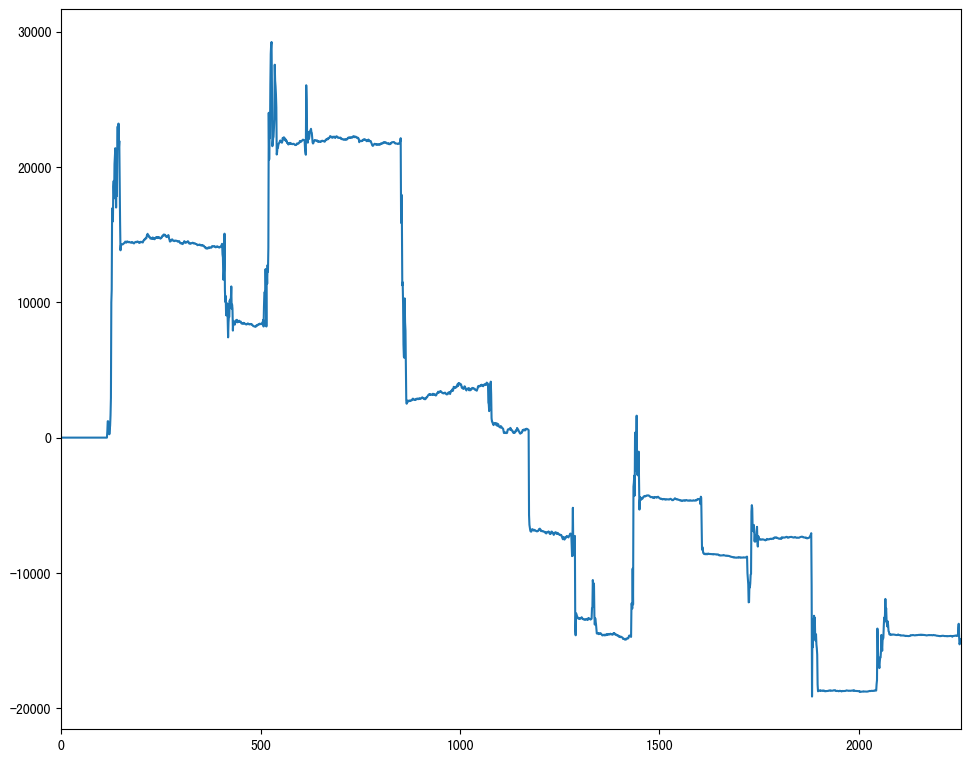

In [8]:
#绘制资金收益曲线（净收益）
x = my_tm.get_profit_curve(stk.get_datetime_list(q), Query.DAY)
#x = my_tm.getFundsCurve(stk.getDatetimeList(q), KQuery.DAY) #总资产曲线
x = PRICELIST(x)
x.plot()

In [9]:
#回测统计
per = my_tm.get_performance()
per.statistics(my_tm, Datetime.now())
print(per.report())

帐户初始金额: 100000.00
累计投入本金: 100000.00
累计投入资产: 0.00
累计借入现金: 0.00
累计借入资产: 0.00
累计红利: 6178.40
现金余额: 42721.94
未平仓头寸净值: 42376.56
当前总资产: 85098.50
已平仓交易总成本: 0.00
已平仓净利润总额: 0.00
单笔交易最大占用现金比例%: 99.89
交易平均占用现金比例%: 99.26
未平仓帐户收益率%: -14.90
已平仓帐户收益率%: 0.00
帐户年复合收益率%: -1.81
帐户平均年收益率%: -1.69
赢利交易赢利总额: 0.00
亏损交易亏损总额: 0.00
已平仓交易总数: 0.00
赢利交易数: 0.00
亏损交易数: 0.00
赢利交易比例%: 0.00
赢利期望值: 0.00
赢利交易平均赢利: 0.00
亏损交易平均亏损: 0.00
平均赢利/平均亏损比例: 0.00
净赢利/亏损比例: 0.00
最大单笔赢利: 0.00
最大单笔盈利百分比%: 0.00
最大单笔亏损: 0.00
最大单笔亏损百分比%: 0.00
赢利交易平均持仓时间: 0.00
赢利交易最大持仓时间: 0.00
亏损交易平均持仓时间: 0.00
亏损交易最大持仓时间: 0.00
空仓总时间: 3221.00
空仓时间/总时间%: 100.00
平均空仓时间: 3221.00
最长空仓时间: 3220.00
最大连续赢利笔数: 0.00
最大连续亏损笔数: 0.00
最大连续赢利金额: 0.00
最大连续亏损金额: 0.00
R乘数期望值: 0.00
交易机会频率/年: 0.00
年度期望R乘数: 0.00
赢利交易平均R乘数: 0.00
亏损交易平均R乘数: 0.00
最大单笔赢利R乘数: 0.00
最大单笔亏损R乘数: 0.00
最大连续赢利R乘数: 0.00
最大连续亏损R乘数: 0.00



<Axes: title={'center': '账户(SYS) 累积收益率'}>

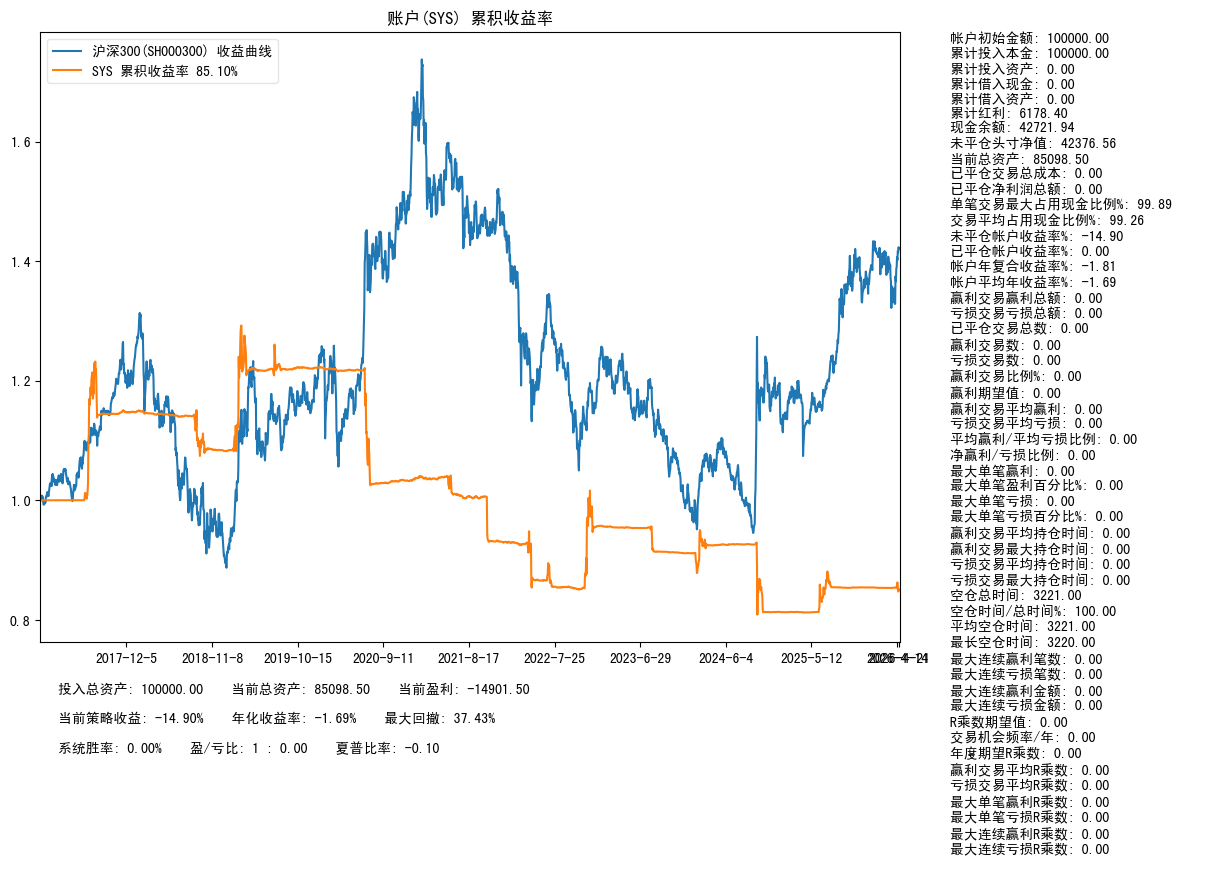

In [10]:
my_sys.performance()

# 五、或许想看下图形

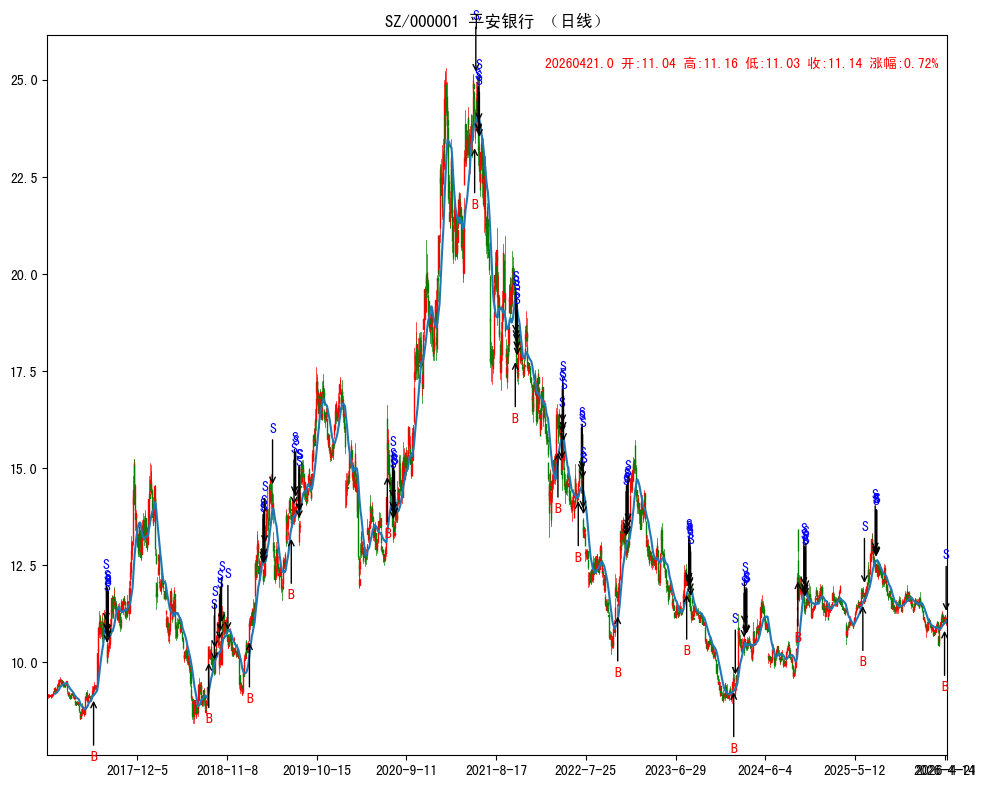

In [11]:
my_sys.plot()
MA(CLOSE(my_sys.to), 20).plot(new=False)

# 六、或许想看看所有股票的情况

In [15]:
import pandas as pd
def calTotal(blk, q):
    per = Performance()
    s_name = []
    s_code = []
    x = []
    for stk in blk:
        my_sys.run(stk, q)
        per.statistics(my_tm, Datetime.now())
        s_name.append(stk.name)
        s_code.append(stk.market_code)
        x.append(per["当前总资产"])
    return pd.DataFrame({'代码': s_code, '股票': s_name, '当前总资产': x})

%time data = calTotal(blocka, q)

CPU times: user 3min 7s, sys: 5.51 s, total: 3min 13s
Wall time: 4min 2s


In [17]:
#保存到CSV文件
data.to_csv(sm.tmpdir() + '/统计.csv')
data

,代码,股票,当前总资产
0,SH603235,天新药业,70751.09
1,SH603976,正川股份,124050.08
2,SH605299,舒华体育,112696.45
3,SH603266,天龙股份,131656.42
4,BJ920508,殷图网联,259574.10
...,...,...,...
3487,BJ920946,森萱医药,78876.24
3488,BJ920961,创远信科,70114.24
3489,BJ920964,润农节水,84135.72
3490,BJ920970,大禹生物,81368.11
